c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


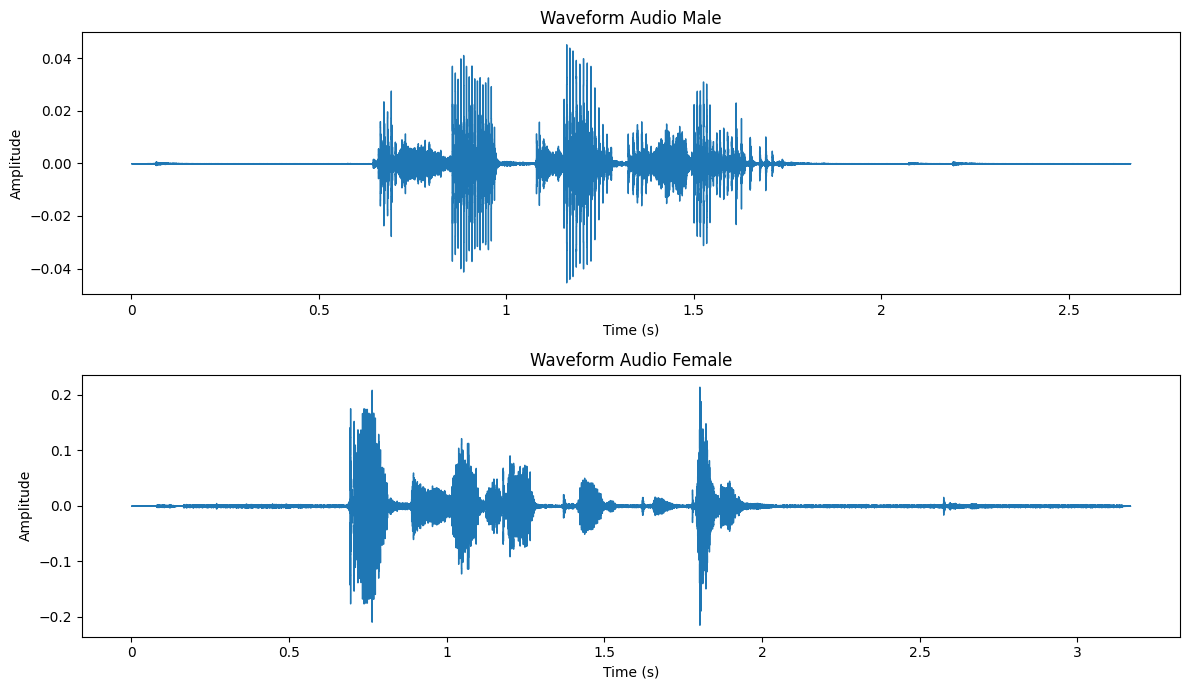

In [1]:
import librosa
import librosa.display
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# WAVEFORM MALE & FEMALE
# ============================================================

metadata_path = 'validated.tsv'
audio_folder = 'clips'

df = pd.read_csv(
    metadata_path,
    sep='\t'
)

male_file = df[
    df["gender"] == "male_masculine"
]["path"].iloc[0]

female_file = df[
    df["gender"] == "female_feminine"
]["path"].iloc[0]

male_path = os.path.join(
    audio_folder,
    male_file
)

female_path = os.path.join(
    audio_folder,
    female_file
)


def preprocess_audio(file_path):

    y, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    pre = 0.97

    y = np.append(
        y[0],
        y[1:] - pre * y[:-1]
    )

    return y, sr


y_male, sr_male = preprocess_audio(
    male_path
)

y_female, sr_female = preprocess_audio(
    female_path
)


# Visualisasi
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12, 7)
)

librosa.display.waveshow(
    y_male,
    sr=sr_male,
    ax=ax[0]
)

ax[0].set_title(
    "Waveform Audio Male"
)

ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")


librosa.display.waveshow(
    y_female,
    sr=sr_female,
    ax=ax[1]
)

ax[1].set_title(
    "Waveform Audio Female"
)

ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()